In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_ValidationData/MICCAI_BraTS2020_ValidationData/name_mapping_validation_data.csv
/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_ValidationData/MICCAI_BraTS2020_ValidationData/survival_evaluation.csv
/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_ValidationData/MICCAI_BraTS2020_ValidationData/BraTS20_Validation_084/BraTS20_Validation_084_flair.nii
/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_ValidationData/MICCAI_BraTS2020_ValidationData/BraTS20_Validation_084/BraTS20_Validation_084_t2.nii
/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_ValidationData/MICCAI_BraTS2020_ValidationData/BraTS20_Validation_084/BraTS20_Validation_084_t1ce.nii
/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_ValidationData/MICCAI_BraTS2020_ValidationData/BraTS20_Validation_084/BraTS20_Vali

In [2]:
import os

root = r"/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData"

all_patients = sorted(os.listdir(root))

valid_patients = []

for p in all_patients:
    p_path = os.path.join(root, p)
    seg_path = os.path.join(p_path, p + "_seg.nii")
    
    if os.path.exists(seg_path):
        valid_patients.append(p)

print("Total folders:", len(all_patients))
print("Patients with segmentation:", len(valid_patients))

Total folders: 371
Patients with segmentation: 368


In [3]:
import nibabel as nib
import numpy as np

def load_nifti(path):
    return nib.load(path).get_fdata()

shapes = set()

for p in valid_patients:
    p_path = os.path.join(root, p)
    seg = load_nifti(os.path.join(p_path, p + "_seg.nii"))
    shapes.add(seg.shape)

print("Unique volume shapes:", shapes)

Unique volume shapes: {(240, 240, 155)}


In [4]:
all_labels = set()

for p in valid_patients[:50]:  # sample for speed
    p_path = os.path.join(root, p)
    seg = load_nifti(os.path.join(p_path, p + "_seg.nii"))
    all_labels.update(np.unique(seg))

print("Unique segmentation labels:", all_labels)

Unique segmentation labels: {np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(4.0)}


In [5]:
tumor_slices = 0
total_slices = 0

for p in valid_patients:
    p_path = os.path.join(root, p)
    seg = load_nifti(os.path.join(p_path, p + "_seg.nii"))
    
    total_slices += seg.shape[2]
    
    for i in range(seg.shape[2]):
        if np.sum(seg[:,:,i]) > 0:
            tumor_slices += 1

print("Total slices:", total_slices)
print("Tumor slices:", tumor_slices)
print("Tumor slice %:", 100 * tumor_slices / total_slices)

Total slices: 57040
Tumor slices: 24354
Tumor slice %: 42.696353436185134


In [6]:
label_distribution = {0:0, 1:0, 2:0, 4:0}

for p in valid_patients[:100]:  # partial for speed
    p_path = os.path.join(root, p)
    seg = load_nifti(os.path.join(p_path, p + "_seg.nii"))
    
    for label in label_distribution.keys():
        label_distribution[label] += np.sum(seg == label)

print(label_distribution)

{0: np.int64(885035293), 1: np.int64(1140885), 2: np.int64(5163680), 4: np.int64(1460142)}


In [7]:
WT = seg > 0

In [8]:
import os
import numpy as np
from sklearn.model_selection import KFold

In [9]:
patients = valid_patients  # from previous step

print("Total valid patients:", len(patients))

Total valid patients: 368


In [10]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

folds = []

for fold, (train_idx, val_idx) in enumerate(kf.split(patients)):
    train_patients = [patients[i] for i in train_idx]
    val_patients = [patients[i] for i in val_idx]
    
    folds.append((train_patients, val_patients))
    
    print(f"\nFold {fold+1}")
    print("Train patients:", len(train_patients))
    print("Validation patients:", len(val_patients))


Fold 1
Train patients: 294
Validation patients: 74

Fold 2
Train patients: 294
Validation patients: 74

Fold 3
Train patients: 294
Validation patients: 74

Fold 4
Train patients: 295
Validation patients: 73

Fold 5
Train patients: 295
Validation patients: 73


In [11]:
import nibabel as nib

def load_nifti(path):
    return nib.load(path).get_fdata()

def extract_slices(patient_list, root):
    images = []
    masks = []
    
    for p in patient_list:
        p_path = os.path.join(root, p)
        
        flair = load_nifti(os.path.join(p_path, p + "_flair.nii"))
        t1ce = load_nifti(os.path.join(p_path, p + "_t1ce.nii"))
        t2 = load_nifti(os.path.join(p_path, p + "_t2.nii"))
        seg = load_nifti(os.path.join(p_path, p + "_seg.nii"))
        
        for i in range(seg.shape[2]):
            
            if np.sum(seg[:,:,i]) > 0:  # Keep tumor slices only
                
                image = np.stack([
                    flair[:,:,i],
                    t1ce[:,:,i],
                    t2[:,:,i]
                ], axis=-1)
                
                mask = (seg[:,:,i] > 0).astype(np.float32)
                
                images.append(image)
                masks.append(mask)
                
    return np.array(images), np.array(masks)

In [12]:
import os
import nibabel as nib
import numpy as np

def load_nifti(path):
    return nib.load(path).get_fdata()

def build_slice_index(patient_list, root):
    slice_index = []

    for p in patient_list:
        p_path = os.path.join(root, p)
        seg = load_nifti(os.path.join(p_path, p + "_seg.nii"))

        for i in range(seg.shape[2]):
            if np.sum(seg[:,:,i]) > 0:
                slice_index.append((p, i))

    return slice_index

In [13]:
train_index = build_slice_index(train_patients, root)
val_index = build_slice_index(val_patients, root)

print("Train slices:", len(train_index))
print("Val slices:", len(val_index))

Train slices: 19428
Val slices: 4926


In [14]:
import torch
from torch.utils.data import Dataset
import cv2

class BraTSDataset(Dataset):
    def __init__(self, slice_index, root):
        self.slice_index = slice_index
        self.root = root

    def __len__(self):
        return len(self.slice_index)

    def __getitem__(self, idx):
        patient, slice_id = self.slice_index[idx]
        p_path = os.path.join(self.root, patient)

        flair = load_nifti(os.path.join(p_path, patient + "_flair.nii"))
        t1ce = load_nifti(os.path.join(p_path, patient + "_t1ce.nii"))
        t2 = load_nifti(os.path.join(p_path, patient + "_t2.nii"))
        seg = load_nifti(os.path.join(p_path, patient + "_seg.nii"))

        image = np.stack([
            flair[:,:,slice_id],
            t1ce[:,:,slice_id],
            t2[:,:,slice_id]
        ], axis=-1)

        mask = (seg[:,:,slice_id] > 0).astype(np.float32)

        # Normalize
        image = (image - np.mean(image)) / (np.std(image) + 1e-8)

        image = torch.tensor(image).permute(2,0,1).float()
        mask = torch.tensor(mask).unsqueeze(0).float()

        return image, mask

In [15]:
from torch.utils.data import DataLoader

train_dataset = BraTSDataset(train_index, root)
val_dataset = BraTSDataset(val_index, root)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=2)

print("Train batches:", len(train_loader))

Train batches: 4857


In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F

def dice_loss(pred, target, smooth=1e-5):
    pred = torch.sigmoid(pred)
    intersection = (pred * target).sum()
    return 1 - (2 * intersection + smooth) / (pred.sum() + target.sum() + smooth)

bce_loss = nn.BCEWithLogitsLoss()

def combined_loss(pred, target):
    return bce_loss(pred, target) + dice_loss(pred, target)

def dice_score(pred, target):
    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()
    intersection = (pred * target).sum()
    return (2 * intersection) / (pred.sum() + target.sum() + 1e-5)

In [17]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super().__init__()

        self.enc1 = DoubleConv(in_channels, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)

        self.pool = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(256, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = DoubleConv(128, 64)

        self.final = nn.Conv2d(64, out_channels, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))

        b = self.bottleneck(self.pool(e3))

        d3 = self.up3(b)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        return self.final(d1)

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet().to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [19]:
import time
import torch

def train_model(model, train_loader, val_loader, optimizer, epochs=10, verbose=True):

    best_val_dice = 0

    for epoch in range(epochs):
        epoch_start = time.time()

        # ==========================
        # TRAIN
        # ==========================
        model.train()
        train_loss = 0
        train_dice = 0
        train_acc = 0

        batch_start_time = time.time()

        for batch_idx, (images, masks) in enumerate(train_loader):
            images = images.to(device)
            masks = masks.to(device)

            preds = model(images)
            loss = combined_loss(preds, masks)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_dice += dice_score(preds, masks).item()

            preds_bin = (torch.sigmoid(preds) > 0.5).float()
            correct = (preds_bin == masks).float().sum()
            total = torch.numel(preds_bin)
            train_acc += (correct / total).item()

            # Verbose every 50 batches
            if verbose and batch_idx % 50 == 0:
                elapsed = time.time() - batch_start_time
                print(f"[Epoch {epoch+1} | Batch {batch_idx}/{len(train_loader)}] "
                      f"Loss: {loss.item():.4f} | Time: {elapsed:.2f}s")
                batch_start_time = time.time()

        train_loss /= len(train_loader)
        train_dice /= len(train_loader)
        train_acc /= len(train_loader)

        # ==========================
        # VALIDATION
        # ==========================
        model.eval()
        val_loss = 0
        val_dice = 0
        val_acc = 0

        with torch.no_grad():
            for images, masks in val_loader:
                images = images.to(device)
                masks = masks.to(device)

                preds = model(images)
                loss = combined_loss(preds, masks)

                val_loss += loss.item()
                val_dice += dice_score(preds, masks).item()

                preds_bin = (torch.sigmoid(preds) > 0.5).float()
                correct = (preds_bin == masks).float().sum()
                total = torch.numel(preds_bin)
                val_acc += (correct / total).item()

        val_loss /= len(val_loader)
        val_dice /= len(val_loader)
        val_acc /= len(val_loader)

        epoch_time = time.time() - epoch_start

        # ==========================
        # EPOCH SUMMARY
        # ==========================
        if verbose:
            print("\n" + "="*60)
            print(f"Epoch [{epoch+1}/{epochs}] - Time: {epoch_time:.2f}s")
            print(f"Train → Loss: {train_loss:.4f} | Dice: {train_dice:.4f} | Acc: {train_acc:.4f}")
            print(f"Val   → Loss: {val_loss:.4f} | Dice: {val_dice:.4f} | Acc: {val_acc:.4f}")
            print("="*60)

        # Save best model
        if val_dice > best_val_dice:
            best_val_dice = val_dice
            torch.save(model.state_dict(), "best_unet.pth")
            if verbose:
                print("🔥 Best model updated!\n")

    return best_val_dice

In [ ]:
best_dice = train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    epochs=10,
    verbose=True
)

print("Best Validation Dice:", best_dice)

[Epoch 1 | Batch 0/4857] Loss: 1.7897 | Time: 4.27s
[Epoch 1 | Batch 50/4857] Loss: 1.4551 | Time: 43.31s
[Epoch 1 | Batch 100/4857] Loss: 1.4628 | Time: 27.93s
[Epoch 1 | Batch 150/4857] Loss: 1.2870 | Time: 22.24s
[Epoch 1 | Batch 200/4857] Loss: 1.1937 | Time: 14.52s
[Epoch 1 | Batch 250/4857] Loss: 1.1003 | Time: 13.62s
[Epoch 1 | Batch 300/4857] Loss: 1.2201 | Time: 11.43s
[Epoch 1 | Batch 350/4857] Loss: 1.1344 | Time: 11.62s
[Epoch 1 | Batch 400/4857] Loss: 1.1827 | Time: 10.54s
[Epoch 1 | Batch 450/4857] Loss: 0.9265 | Time: 10.50s
[Epoch 1 | Batch 500/4857] Loss: 1.1380 | Time: 11.21s
[Epoch 1 | Batch 550/4857] Loss: 0.9803 | Time: 10.82s
[Epoch 1 | Batch 600/4857] Loss: 1.0628 | Time: 10.17s
[Epoch 1 | Batch 650/4857] Loss: 1.0287 | Time: 10.79s
[Epoch 1 | Batch 700/4857] Loss: 0.8640 | Time: 10.41s
[Epoch 1 | Batch 750/4857] Loss: 1.1221 | Time: 10.47s
[Epoch 1 | Batch 800/4857] Loss: 0.7282 | Time: 10.49s
[Epoch 1 | Batch 850/4857] Loss: 0.6435 | Time: 10.45s
[Epoch 1 | Bat

In [1]:
!pip install git+https://github.com/facebookresearch/segment-anything.git

  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-urp6fcwi
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-urp6fcwi
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py) ... done


In [7]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from skimage.transform import resize
from segment_anything import sam_model_registry, SamPredictor

In [12]:
%whos

Variable             Type        Data/Info
------------------------------------------
SamPredictor         type        <class 'segment_anything.predictor.SamPredictor'>
np                   module      <module 'numpy' from '/us<...>kages/numpy/__init__.py'>
plt                  module      <module 'matplotlib.pyplo<...>es/matplotlib/pyplot.py'>
resize               function    <function resize at 0x7fb846cafc40>
sam_model_registry   dict        n=4
torch                module      <module 'torch' from '/us<...>kages/torch/__init__.py'>


In [13]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_ValidationData/MICCAI_BraTS2020_ValidationData/name_mapping_validation_data.csv
/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_ValidationData/MICCAI_BraTS2020_ValidationData/survival_evaluation.csv
/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_ValidationData/MICCAI_BraTS2020_ValidationData/BraTS20_Validation_084/BraTS20_Validation_084_flair.nii
/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_ValidationData/MICCAI_BraTS2020_ValidationData/BraTS20_Validation_084/BraTS20_Validation_084_t2.nii
/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_ValidationData/MICCAI_BraTS2020_ValidationData/BraTS20_Validation_084/BraTS20_Validation_084_t1ce.nii
/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_ValidationData/MICCAI_BraTS2020_ValidationData/BraTS20_Validation_084/BraTS20_Vali

In [15]:
import nibabel as nib
import numpy as np

flair_path = "/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_108/BraTS20_Training_108_flair.nii"
mask_path  = "/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_309/BraTS20_Training_309_seg.nii"

flair = nib.load(flair_path).get_fdata()
mask  = nib.load(mask_path).get_fdata()

print("Flair shape:", flair.shape)
print("Mask shape:", mask.shape)

Flair shape: (240, 240, 155)
Mask shape: (240, 240, 155)


In [16]:
images = []
masks = []

for i in range(flair.shape[2]):  # iterate over 155 slices
    
    img_slice = flair[:, :, i]
    mask_slice = mask[:, :, i]
    
    # Keep only slices that contain tumor
    if np.sum(mask_slice) > 0:
        images.append(img_slice)
        masks.append(mask_slice)

images = np.array(images)
masks = np.array(masks)

print("Images shape:", images.shape)
print("Masks shape:", masks.shape)

Images shape: (73, 240, 240)
Masks shape: (73, 240, 240)


In [17]:
slice_id = 10   # you can change later

image = images[slice_id]
mask = masks[slice_id]

print("Selected slice shape:", image.shape)

Selected slice shape: (240, 240)


In [18]:
import numpy as np

image_3ch = np.stack([image, image, image], axis=-1)

print("3-channel shape:", image_3ch.shape)

3-channel shape: (240, 240, 3)


In [19]:
from skimage.transform import resize

image_resized = resize(image_3ch, (1024, 1024), preserve_range=True)
mask_resized = resize(mask, (1024, 1024), order=0, preserve_range=True)

print("Resized shape:", image_resized.shape)

Resized shape: (1024, 1024, 3)


In [20]:
!wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

--2026-02-22 19:52:51--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 3.163.189.108, 3.163.189.14, 3.163.189.51, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|3.163.189.108|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 375042383 (358M) [binary/octet-stream]
Saving to: ‘sam_vit_b_01ec64.pth’

sam_vit_b_01ec64.pt 100%[===================>] 357.67M   390MB/s    in 0.9s    

2026-02-22 19:52:52 (390 MB/s) - ‘sam_vit_b_01ec64.pth’ saved [375042383/375042383]



In [21]:
import torch
from segment_anything import sam_model_registry, SamPredictor

device = "cuda" if torch.cuda.is_available() else "cpu"

sam = sam_model_registry["vit_b"](checkpoint="sam_vit_b_01ec64.pth")
sam.to(device)

predictor = SamPredictor(sam)

print("SAM loaded successfully")

SAM loaded successfully


In [22]:
predictor.set_image(image_resized.astype(np.uint8))

In [23]:
y_indices, x_indices = np.where(mask_resized > 0)

x_min, x_max = x_indices.min(), x_indices.max()
y_min, y_max = y_indices.min(), y_indices.max()

box = np.array([x_min, y_min, x_max, y_max])

print("Bounding Box:", box)

Bounding Box: [380 589 558 750]


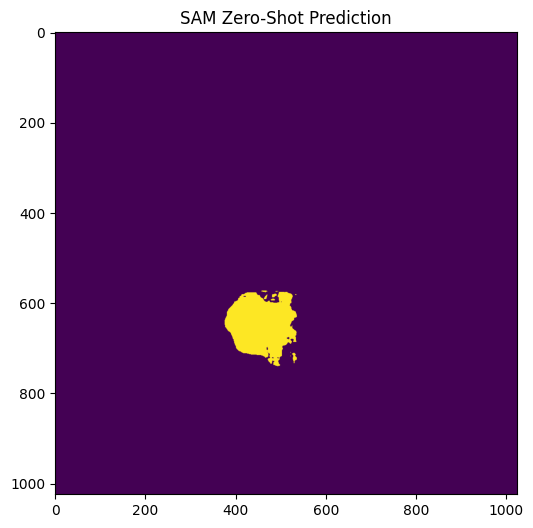

In [24]:
masks_pred, scores, logits = predictor.predict(
    box=box,
    multimask_output=False
)

import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.imshow(masks_pred[0])
plt.title("SAM Zero-Shot Prediction")
plt.show()

In [25]:
def dice_score(pred, gt):
    intersection = np.sum(pred * gt)
    return (2. * intersection) / (np.sum(pred) + np.sum(gt) + 1e-8)

dice = dice_score(masks_pred[0], mask_resized)

print("Zero-shot Dice Score:", dice)

Zero-shot Dice Score: 0.8472653932848863


In [26]:
for param in sam.image_encoder.parameters():
    param.requires_grad = False

print("Image encoder frozen")

Image encoder frozen


In [27]:
optimizer = torch.optim.Adam(
    sam.mask_decoder.parameters(),
    lr=1e-4
)

print("Optimizer ready")

Optimizer ready


In [31]:
import torch.nn as nn

bce = nn.BCEWithLogitsLoss()

def dice_loss(pred, target):
    pred = torch.sigmoid(pred)
    intersection = (pred * target).sum()
    return 1 - (2. * intersection) / (pred.sum() + target.sum() + 1e-8)

In [33]:
epochs = 3   # start small

for epoch in range(epochs):
    
    total_loss = 0
    
    for i in range(len(images)):
        
        # Prepare image
        img = images[i]
        msk = masks[i]
        
        img_3ch = np.stack([img, img, img], axis=-1)
        
        img_resized = resize(img_3ch, (1024,1024), preserve_range=True)
        msk_resized = resize(msk, (256,256), order=0, preserve_range=True)
        
        image_tensor = torch.tensor(img_resized).permute(2,0,1).unsqueeze(0).float().to(device)
        mask_tensor = torch.tensor(msk_resized).unsqueeze(0).unsqueeze(0).float().to(device)
        
        # Bounding box
        y_idx, x_idx = np.where(msk_resized > 0)
        x_min, x_max = x_idx.min(), x_idx.max()
        y_min, y_max = y_idx.min(), y_idx.max()
        box_tensor = torch.tensor([[x_min, y_min, x_max, y_max]]).float().to(device)
        
        # Forward pass
        image_embedding = sam.image_encoder(image_tensor)
        
        sparse_embeddings, dense_embeddings = sam.prompt_encoder(
            points=None,
            boxes=box_tensor,
            masks=None,
        )
        
        low_res_masks, _ = sam.mask_decoder(
            image_embeddings=image_embedding,
            image_pe=sam.prompt_encoder.get_dense_pe(),
            sparse_prompt_embeddings=sparse_embeddings,
            dense_prompt_embeddings=dense_embeddings,
            multimask_output=False,
        )
        
        loss = dice_loss(low_res_masks, mask_tensor) + bce(low_res_masks, mask_tensor)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(images)}")

Epoch 1, Loss: -0.04649680322163725
Epoch 2, Loss: -0.6015570095344765
Epoch 3, Loss: 1.112666446256311
